# Load dataset

In [1]:
from tensorflow.keras.datasets import cifar10
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Flatten the images (from 32x32x3 to 3072 features)
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

# Downsample for speed
subset_idx = np.random.choice(len(x_train), size=2000, replace=False)
X = x_train[subset_idx]
y = y_train[subset_idx]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Create model without tuning

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
import numpy as np

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Fit fixed model (no tuning)
fixed_model = SVC(C=1, kernel='rbf', probability=True)
fixed_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = fixed_model.predict(X_test)
y_prob = fixed_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=np.unique(y))

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')

print("🔹 Base Model (No Tuning)")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")


🔹 Base Model (No Tuning)
Accuracy: 0.3960
F1 Score: 0.3829
AUC Score: 0.8150


# Tune a model

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
import numpy as np

# Reuse your earlier train/test split
# (If not already split, do this first)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01, 0.001]  # RBF kernel width (controls decision boundary complexity)
}

# Grid search
svc = SVC(probability=True)
grid = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=np.unique(y))

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')

print("🔹 Tuned Model (GridSearchCV)")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
🔹 Tuned Model (GridSearchCV)
Accuracy: 0.4020
F1 Score: 0.3995
AUC Score: 0.8249


# Sensitivity Analysis

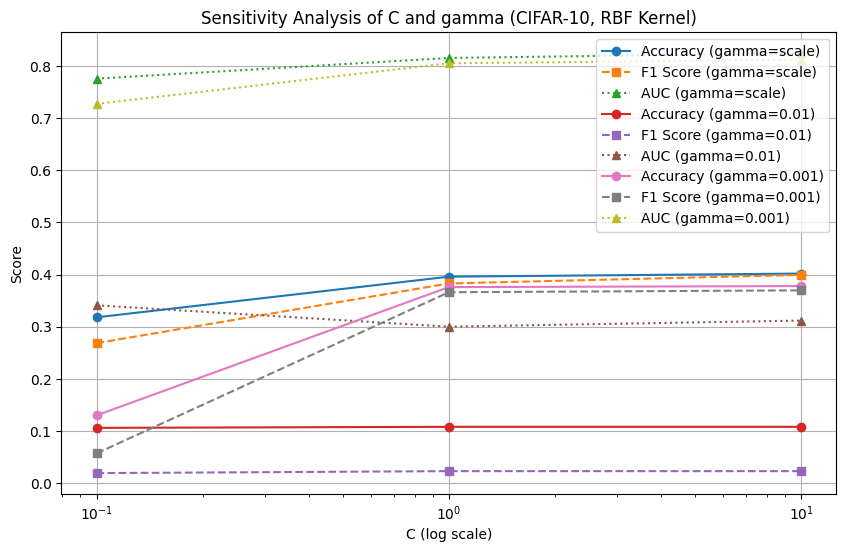

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Define parameters
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.001]

# Store results as a dictionary of lists for each gamma
results = {gamma: {'acc': [], 'f1': [], 'auc': []} for gamma in gamma_values}

# Fixed train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Sensitivity analysis: loop over C and gamma
for gamma in gamma_values:
    for C in C_values:
        model = SVC(C=C, kernel='rbf', gamma=gamma, probability=True)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')

        results[gamma]['acc'].append(acc)
        results[gamma]['f1'].append(f1)
        results[gamma]['auc'].append(auc)

# Plotting
plt.figure(figsize=(10, 6))
for gamma in gamma_values:
    plt.plot(C_values, results[gamma]['acc'], marker='o', label=f'Accuracy (gamma={gamma})')
    plt.plot(C_values, results[gamma]['f1'], marker='s', linestyle='--', label=f'F1 Score (gamma={gamma})')
    plt.plot(C_values, results[gamma]['auc'], marker='^', linestyle=':', label=f'AUC (gamma={gamma})')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Sensitivity Analysis of C and gamma (CIFAR-10, RBF Kernel)")
plt.legend()
plt.grid(True)
plt.show()


# Findings

Although the AUC is quite high, the accuracy and F1 scores are extremely low.

These results suggest that regardless of any parameter tuning on an SVM model, it will not yield accurate classification results.